In [1]:
import matplotlib
import matplotlib.pyplot as plt
#from collections import OrderedDict
import seaborn as sns

import numpy as np
import os
import scipy
import pickle

from neurolib.models.aln import ALNModel
import neurolib.utils.functions as func
from neurolib.utils import costFunctions as cost
from neurolib.utils import plotFunctions as plotFunc

# a nice color map
#sns.set()
#cmap = plt.get_cmap('plasma')
plt.rcParams['image.cmap'] = 'plasma'
cpalette = sns.color_palette('plasma')
np.set_printoptions(precision=4)

#matplotlib.style.use('classic')

font = {
    'family' : 'sans',
    'weight' : 'normal',
    'size'   : 14
       }

matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=16) 
matplotlib.rc('ytick', labelsize=16) 
matplotlib.rc('grid', c='0.5', ls='-', lw=0.5)  # solid gray grid lines
matplotlib.rc('savefig', dpi=300)       # higher res outputs
#print (matplotlib.rcParams)
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

path = os.getcwd()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Bistability

In [8]:
aln = ALNModel()
#aln = RateModel()

state_vars = aln.state_vars
init_vars = aln.init_vars

def step_control(maxI_ = 1.):
    control_ = aln.getZeroControl()
    for i_time in range(control_.shape[2]):
        if ( float(i_time/control_.shape[2]) < 0.1):
            control_[:,:1,i_time] = - maxI_
        elif ( float(i_time/control_.shape[2]) > 0.5 and float(i_time/control_.shape[2]) < 0.6 ):
            control_[:,:1,i_time] = maxI_
    return control_

def setinit(init_vars_):
    for iv in range(len(init_vars)):
        for sv in range(len(state_vars)):
            if state_vars[sv] in init_vars[iv]:
                #print("set init vars ", )
                if aln.params[init_vars[iv]].ndim == 2:
                    aln.params[init_vars[iv]][0,:] = init_vars_[sv]
                else:
                    aln.params[init_vars[iv]][0] = init_vars_[sv]

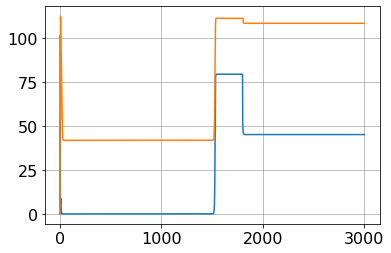

[[4.5199e+01 1.0858e+02]
 [4.4786e-05 4.1919e+01]]


In [9]:
aln.params['duration'] = 3000.

control0 = aln.getZeroControl()
target = aln.getZeroTarget()
control0 = step_control(maxI_ = 1.)

aln.params.ext_exc_current = 2.5
aln.params.ext_inh_current = 3.

aln.params.mue_ext_mean = 0.0
aln.params.mui_ext_mean = 0.0

# NO ADAPTATION
aln.params.IA_init = np.array([0.])
aln.params.a = 0.
aln.params.b = 0.

aln.run(control = control0)

plt.plot(aln.t, aln.rates_exc[0,:])
plt.plot(aln.t, aln.rates_inh[0,:])
plt.show()
    
steady_rates = np.zeros((2, 2))
steady_rates[0,0] = aln.rates_exc[0,-1] # high state exc
steady_rates[0,1] = aln.rates_inh[0,-1] # high state inh
steady_rates[1,0] = aln.rates_exc[0,14500] # low state exc
steady_rates[1,1] = aln.rates_inh[0,14500] # low state inh

print(steady_rates)

high_state_vars = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    #print("final value of state var ", aln.state_vars[i], " : ", aln.state[state_vars[i]])
    if aln.state[state_vars[i]].size == 1:
        high_state_vars[i] = aln.state[state_vars[i]][0] * 1.1
    else:
        high_state_vars[i] = aln.state[state_vars[i]][0,-1] * 1.1

low state vars =  [ 4.0307e-005  3.7727e+001 -3.1597e-001  1.3311e+000  0.0000e+000
  7.9618e-006  7.7757e-001  7.4412e-006  8.3469e-001  4.9146e-007
  1.1664e-003  4.2930e-007  7.8039e-004  2.1806e-264  1.6354e-264
  1.3556e+000  1.3505e+000 -6.4824e+001  1.9319e+001  1.1760e+000]


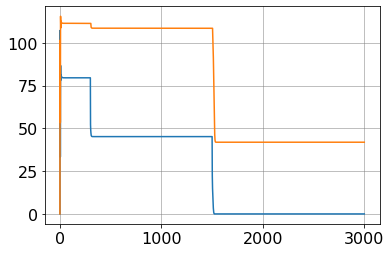

In [10]:
control0 = step_control(maxI_ = -1.)
aln.run(control = control0)
plt.plot(aln.t, aln.rates_exc[0,:])
plt.plot(aln.t, aln.rates_inh[0,:])

low_state_vars = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    #print("final value of state var ", aln.state_vars[i], " : ", aln.state[state_vars[i]])
    if aln.state[state_vars[i]].size == 1:
        low_state_vars[i] = aln.state[state_vars[i]][0] * 0.9
    else:
        low_state_vars[i] = aln.state[state_vars[i]][0,-1] * 0.9

print("low state vars = ", low_state_vars)

### B

In [11]:
dur = 50
dur_pre = 10
dur_post = 10
aln.params.duration = dur

n_dur = int(np.around(dur/aln.params.dt + 1.,1))
n_pre = int(np.around(dur_pre/aln.params.dt + 1.,1))
n_post = int(np.around(dur_post/aln.params.dt + 1.,1))

control0 = aln.getZeroControl()

# set low state rates as target
target_hl = aln.getZeroTarget()
target_hl[:,0,:] = steady_rates[1,0]
target_hl[:,1,:] = steady_rates[1,1]

tol = 1e-12
start_step = 10.

c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

In [14]:
# B.1) high => low, max current 1nA, precision only
case = "B1"
cost.setParams(1.0, 0.0, 0.0)
max_cntrl = 1. * 5.
min_cntrl = - max_cntrl
cntrl_vars = [0,1]
prec_vars = [0,1]
aln.params.duration = dur

max_it = 200

setinit(high_state_vars)
control0 = aln.getZeroControl()
control1 = bestControlB1[:,:,n_pre:-n_post]

# "HS", "FR", "PR", "HZ"
cgv = None

opt_params = {"max_it": max_it,
              "tol": tol,
              "start_step": start_step,
              "dur": dur,
              "dur_pre": dur_pre,
              "dur_post": dur_post,
              "cg_variant": cgv
}

bestControlB1, bestStateB1, costB1, runtimeB1, gradB1 = aln.A1(control0, target_hl, c_scheme, u_mat, u_scheme,
            max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step,
            max_control_ = max_cntrl, min_control_ = min_cntrl,
            t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post,
            CGVar = cgv, control_variables_ = cntrl_vars, prec_variables_ = prec_vars, separate_comp = True)

resultB1 = {"Opt_control": bestControlB1,
              "Opt_state": bestStateB1,
              "costArray": costB1,
              "runtimeArray": runtimeB1,    
}

dump_dicts = [opt_params, aln.params, resultB1]
filename = str(case + "_" + ".p")
pickle.dump( dump_dicts, open( filename, "wb" ) )

set cost params
RUN  0 , total integrated cost =  162526.4355594569
RUN  1 , total integrated cost =  12607.120788758977
RUN  2 , total integrated cost =  1326.6110636562803
RUN  3 , total integrated cost =  872.5692530270654
RUN  4 , total integrated cost =  813.9681464792553
RUN  5 , total integrated cost =  806.200085513578
RUN  6 , total integrated cost =  802.0244101623733
RUN  7 , total integrated cost =  799.2179250439987
RUN  8 , total integrated cost =  797.2152207585816
RUN  9 , total integrated cost =  795.6928605854403
RUN  10 , total integrated cost =  794.5906262374657
RUN  11 , total integrated cost =  794.4032452232876
RUN  12 , total integrated cost =  794.2818749079972
RUN  13 , total integrated cost =  794.1839408877962
RUN  14 , total integrated cost =  794.0984861554058
RUN  15 , total integrated cost =  794.0222166293097
RUN  16 , total integrated cost =  793.9529498281894
RUN  17 , total integrated cost =  793.8898270343677
RUN  18 , total integrated cost =  793.

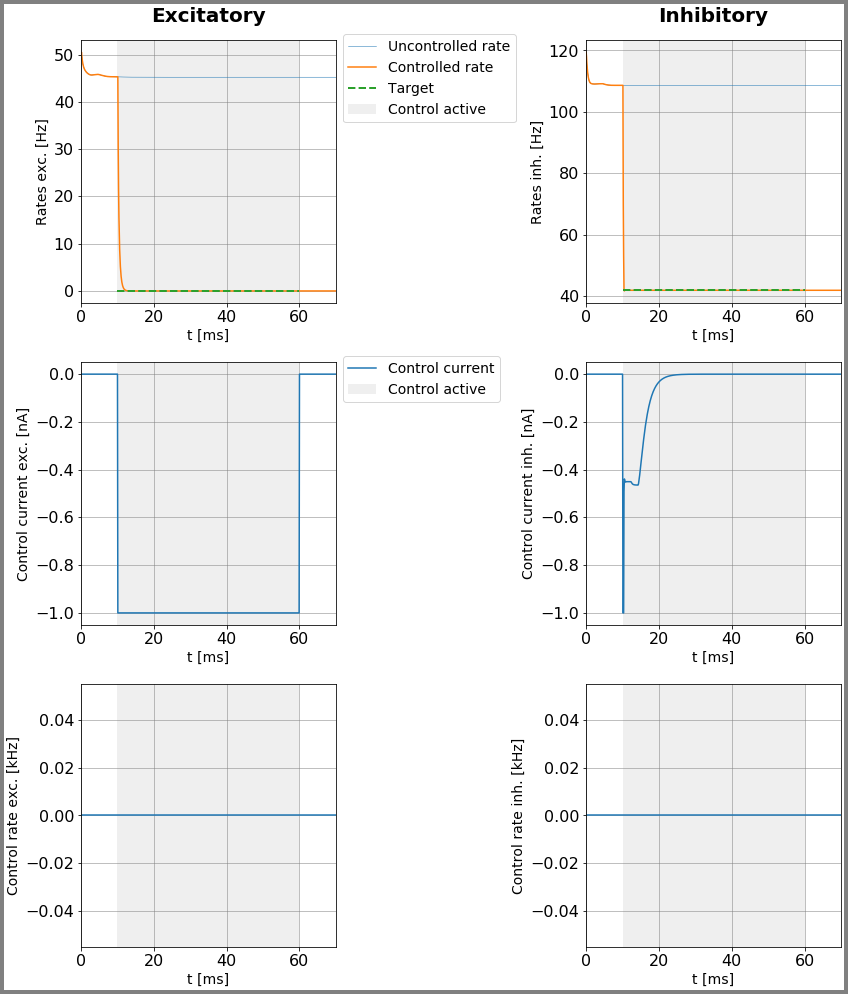

In [15]:
plotFunc.plot_control(aln, bestControlB1, dur, dur_pre, dur_post, high_state_vars, target_hl,
                      path, filename_ = case )

In [19]:
# B.2) high => low, max current 1nA, precision + energy + sparsity
case = "B2"
cost.setParams(1.0, 80.0, 80.0)
max_cntrl = 1. * 5.
min_cntrl = - max_cntrl
cntrl_vars = [0,1]
prec_vars = [0,1]
aln.params.duration = dur

max_it = 30

setinit(high_state_vars)
control0 = aln.getZeroControl()
control1 = bestControlB1[:,:,n_pre-1:-n_pre+1]
control2 = bestControlB2[:,:,n_pre-1:-n_pre+1]

# "HS", "FR", "PR", "HZ"
cgv = None

opt_params = {"max_it": max_it,
              "tol": tol,
              "start_step": start_step,
              "dur": dur,
              "dur_pre": dur_pre,
              "dur_post": dur_post,
              "cg_variant": cgv
}

bestControlB2, bestStateB2, costB2, runtimeB2, gradB2 = aln.A1(control1, target_hl, c_scheme, u_mat, u_scheme,
            max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step,
            max_control_ = max_cntrl, min_control_ = min_cntrl,
            t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post,
            CGVar = cgv, control_variables_ = cntrl_vars, prec_variables_ = prec_vars, separate_comp = True)

resultB2 = {"Opt_control": bestControlB2,
              "Opt_state": bestStateB2,
              "costArray": costB2,
              "runtimeArray": runtimeB2,    
}

dump_dicts = [opt_params, aln.params, resultB2]
filename = str(case + "_" + ".p")
pickle.dump( dump_dicts, open( filename, "wb" ) )

set cost params
RUN  0 , total integrated cost =  4426.968894466154
RUN  1 , total integrated cost =  4426.4758611569905
RUN  2 , total integrated cost =  4426.273201276354
RUN  3 , total integrated cost =  4426.216141123928
RUN  4 , total integrated cost =  4426.175184549717
RUN  5 , total integrated cost =  4426.134588148202
RUN  6 , total integrated cost =  4426.120517194506
RUN  7 , total integrated cost =  4426.0293755442435
RUN  8 , total integrated cost =  4426.017971120492


ERROR:root:Problem in initial value trasfer


RUN  9 , total integrated cost =  4426.0179711204855
Control only changes marginally.
RUN  9 , total integrated cost =  4426.0179711204855
Improved over  9  iterations by  0.021480235536714076  percent.
Problem in initial value trasfer:  Vmean_exc -69.83566805523316 -69.84595680994684


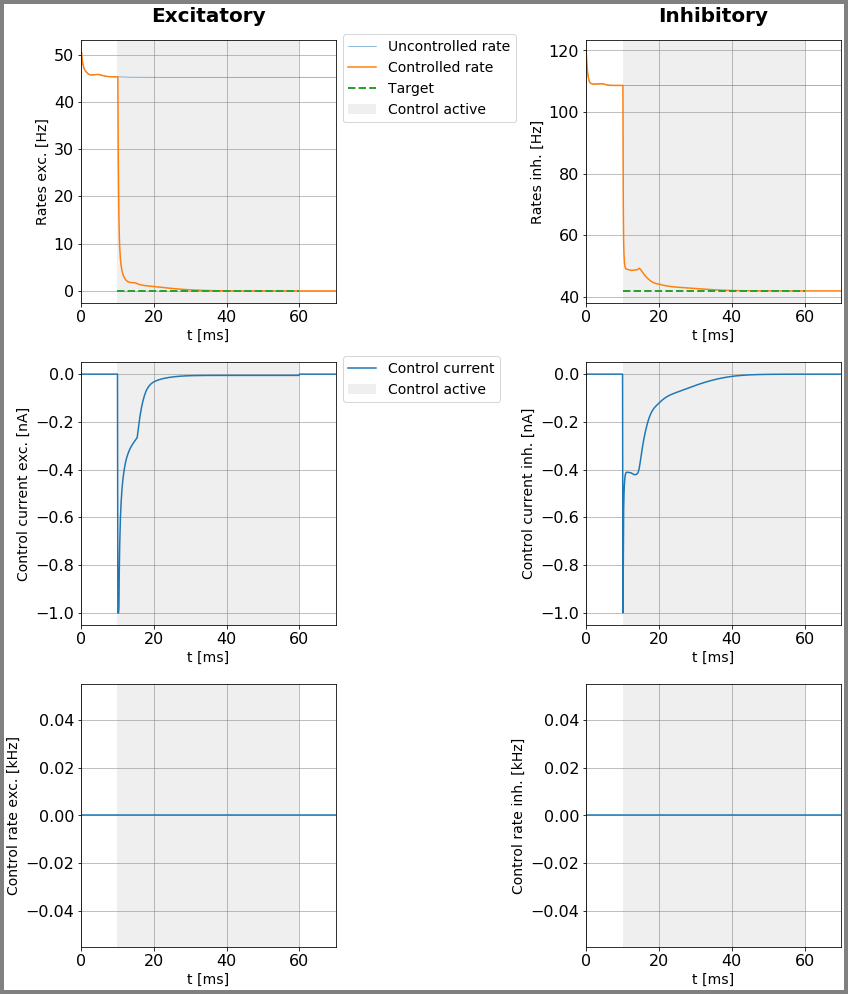

In [20]:
plotFunc.plot_control(aln, bestControlB2, dur, dur_pre, dur_post, high_state_vars, target_hl,
                      path, filename_ = case )